In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
path = kagglehub.dataset_download('kritikseth/fruit-and-vegetable-image-recognition')

print('Data source import complete.')
print(path)

Data source import complete.
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
from pathlib import Path

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_1.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_10.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_2.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_3.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_4.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_5.jpg
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_6.JPG
C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\test\apple\Image_7.jpg
C:\User

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.20.0


In [4]:
from pathlib import Path

BASE_DIR = Path().resolve()


In [5]:

from pathlib import Path
data_root = Path(r"C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8")
print(data_root.exists())


True


In [6]:
train_dir = data_root / "train"
test_dir = data_root / "test"
val_dir = data_root / "validation"
print("train exists:",train_dir.exists())
print("test exists:",test_dir.exists())
print("val exists:",val_dir.exists())


train exists: True
test exists: True
val exists: True


In [7]:
def get_images(folder: Path):
    if not folder.exists():
        return []
    return sorted(list(folder.rglob("*.jpg")) + list(folder.rglob("*.jpeg")) + list(folder.rglob("*.png")))

train_filepaths = get_images(train_dir)
test_filepaths  = get_images(test_dir)
val_filepaths   = get_images(val_dir)

print("Train images:", len(train_filepaths))
print("Test  images:", len(test_filepaths))
print("Val   images:", len(val_filepaths))

# helper to get label from filepath
def get_label(fp: Path):
    return Path(fp).parent.name

# show one example
if train_filepaths:
    print("Example:", train_filepaths[0])
    print("Label  :", get_label(train_filepaths[0]))


Train images: 3115
Test  images: 359
Val   images: 351
Example: C:\Users\golis\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8\train\apple\Image_1.jpg
Label  : apple


In [26]:
import pandas as pd

def build_dataframe(filepaths):
    df = pd.DataFrame({
        "filepath": [str(fp) for fp in filepaths],
        "label": [fp.parent.name for fp in filepaths]
    })
    df = df.sample(frac=1).reset_index(drop=True)
    return df
train_df = build_dataframe(train_filepaths)
test_df = build_dataframe(test_filepaths)
val_df = build_dataframe(val_filepaths)

train_df.head()
val_df.head()
test_df.head()


,filepath,label
0,C:\Users\golis\.cache\kagglehub\datasets\kriti...,raddish
1,C:\Users\golis\.cache\kagglehub\datasets\kriti...,peas
2,C:\Users\golis\.cache\kagglehub\datasets\kriti...,cauliflower
3,C:\Users\golis\.cache\kagglehub\datasets\kriti...,soy beans
4,C:\Users\golis\.cache\kagglehub\datasets\kriti...,soy beans


In [27]:
print('\n-- Training set --\n')
print(f"Number of pictures: {train_df.shape[0]}\n")
print(f"Number of different labels: {train_df['label'].nunique()}\n")
print(f"Labels: {train_df['label'].unique()}\n")
train_df.head(5)


-- Training set --

Number of pictures: 3115

Number of different labels: 36

Labels: ['lettuce' 'banana' 'eggplant' 'mango' 'capsicum' 'turnip' 'ginger'
 'sweetcorn' 'sweetpotato' 'apple' 'beetroot' 'cauliflower' 'cucumber'
 'onion' 'raddish' 'pear' 'soy beans' 'orange' 'corn' 'jalepeno' 'cabbage'
 'pineapple' 'garlic' 'potato' 'grapes' 'paprika' 'spinach' 'bell pepper'
 'lemon' 'watermelon' 'kiwi' 'carrot' 'peas' 'pomegranate' 'tomato'
 'chilli pepper']



,filepath,label
0,C:\Users\golis\.cache\kagglehub\datasets\kriti...,lettuce
1,C:\Users\golis\.cache\kagglehub\datasets\kriti...,banana
2,C:\Users\golis\.cache\kagglehub\datasets\kriti...,eggplant
3,C:\Users\golis\.cache\kagglehub\datasets\kriti...,mango
4,C:\Users\golis\.cache\kagglehub\datasets\kriti...,capsicum


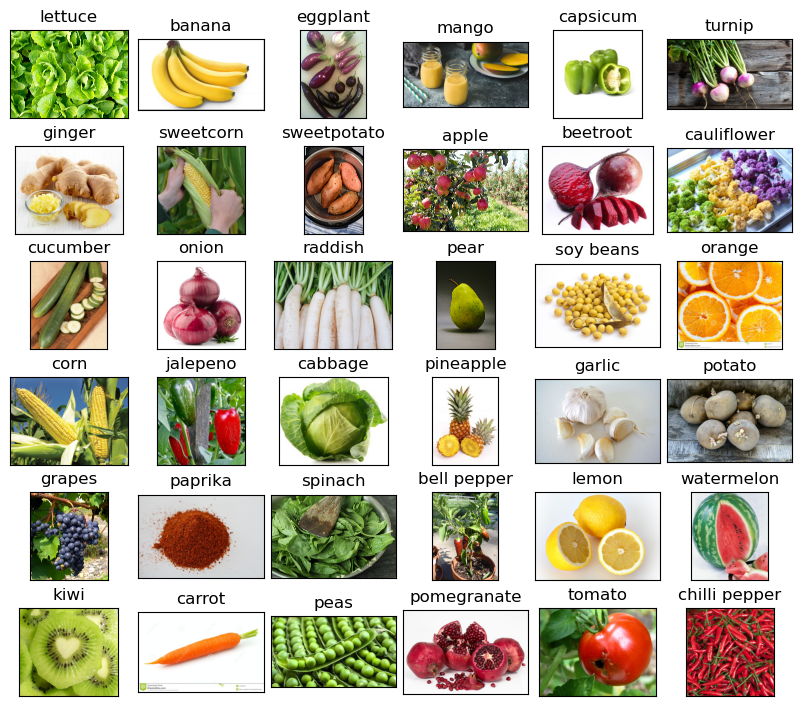

In [28]:
df_unique = train_df.copy().drop_duplicates(subset=["label"]).reset_index(drop=True)

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.filepath[i]))
    ax.set_title(df_unique.label[i], fontsize=12)

plt.tight_layout(pad=0.5)
plt.show()

In [29]:
IMG_SIZE = (224, 224)
input_shape = (224, 224, 3)
BATCH_SIZE = 32
SEED = 42

In [30]:
val_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

val_flow = val_generator.flow_from_directory(
    directory=str(val_dir),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


Found 351 images belonging to 36 classes.


In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)


In [32]:
train_flow = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


Found 3115 validated image filenames belonging to 36 classes.


In [33]:
val_flow = val_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 351 validated image filenames belonging to 36 classes.


In [34]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [35]:
test_flow = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 359 validated image filenames belonging to 36 classes.


In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = 36

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # important

In [37]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)



In [38]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "fruit_veg_mobilenetv2_best.h5",
        monitor="val_loss",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]


In [40]:
history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
12/98 ━━━━━━━━━━━━━━━━━━━━ 2:30 2s/step - accuracy: 0.0692 - loss: 4.1334

c:\Users\golis\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2515 - loss: 2.9879

98/98 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.4315 - loss: 2.1472 - val_accuracy: 0.8091 - val_loss: 0.7734 - learning_rate: 0.0010
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7135 - loss: 0.9964

98/98 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.7204 - loss: 0.9548 - val_accuracy: 0.8775 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7701 - loss: 0.7564

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8844 - loss: 0.3488 - val_accuracy: 0.9345 - val_loss: 0.2341 - learning_rate: 0.0010
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8953 - loss: 0.3388

98/98 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8925 - loss: 0.3358 - val_accuracy: 0.9402 - val_loss: 0.2280 - learning_rate: 0.0010
Epoch 13/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9029 - loss: 0.2969

98/98 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.8970 - loss: 0.3180 - val_accuracy: 0.9430 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 14/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.8989 - loss: 0.3103 - val_accuracy: 0.9288 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 15/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9103 - loss: 0.2843

98/98 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9024 - loss: 0.3002 - val_accuracy: 0.9373 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch 16/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.9101 - loss: 0.2793 - val_accuracy: 0.9373 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 17/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.9014 - loss: 0.2867 - val_accuracy: 0.9402 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 18/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.9130 - loss: 0.2645 - val_accuracy: 0.9288 - val_loss: 0.2161 - learning_rate: 0.0010
Epoch 19/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9178 - loss: 0.2342

98/98 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9220 - loss: 0.2273 - val_accuracy: 0.9430 - val_loss: 0.2052 - learning_rate: 3.0000e-04
Epoch 20/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.9152 - loss: 0.2430 - val_accuracy: 0.9459 - val_loss: 0.2066 - learning_rate: 3.0000e-04


In [41]:
test_loss, test_acc = model.evaluate(test_flow)
print("Test accuracy:", test_acc)


12/12 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9443 - loss: 0.2056
Test accuracy: 0.9442896842956543


In [42]:
# Unfreeze top layers of MobileNetV2
base_model.trainable = True

# Freeze bottom layers, unfreeze top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [43]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [44]:
history_ft = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
 5/98 ━━━━━━━━━━━━━━━━━━━━ 2:50 2s/step - accuracy: 0.7521 - loss: 0.6096

c:\Users\golis\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.8212 - loss: 0.5248 - val_accuracy: 0.8946 - val_loss: 0.3023 - learning_rate: 1.0000e-04
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.8764 - loss: 0.3548 - val_accuracy: 0.9174 - val_loss: 0.2736 - learning_rate: 1.0000e-04
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.9011 - loss: 0.2805 - val_accuracy: 0.9145 - val_loss: 0.2254 - learning_rate: 1.0000e-04
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9265 - loss: 0.2118 - val_accuracy: 0.9259 - val_loss: 0.2073 - learning_rate: 3.0000e-05
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9264 - loss: 0.2193

98/98 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - accuracy: 0.9303 - loss: 0.2055 - val_accuracy: 0.9430 - val_loss: 0.1769 - learning_rate: 3.0000e-05
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9313 - loss: 0.1924

98/98 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9339 - loss: 0.1897 - val_accuracy: 0.9487 - val_loss: 0.1647 - learning_rate: 3.0000e-05
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9362 - loss: 0.1817

98/98 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9422 - loss: 0.1701 - val_accuracy: 0.9544 - val_loss: 0.1581 - learning_rate: 3.0000e-05
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9436 - loss: 0.1742

98/98 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.9502 - loss: 0.1650 - val_accuracy: 0.9487 - val_loss: 0.1534 - learning_rate: 3.0000e-05
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9499 - loss: 0.1534

98/98 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9486 - loss: 0.1539 - val_accuracy: 0.9601 - val_loss: 0.1391 - learning_rate: 3.0000e-05
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9472 - loss: 0.1473

98/98 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.9448 - loss: 0.1520 - val_accuracy: 0.9601 - val_loss: 0.1361 - learning_rate: 3.0000e-05


In [49]:
model.save("fruit_veg_mobilenetv2.keras")


In [50]:
import json

BASE_DIR = Path().resolve()
CLASS_PATH = BASE_DIR / "class_names.json"
class_indices = train_flow.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

with open(CLASS_PATH, "w") as f:
    json.dump(idx_to_class, f)


In [52]:
import tensorflow as tf
import json
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load model
BASE_DIR = Path().resolve()
MODEL_PATH = BASE_DIR / "fruit_veg_mobilenetv2.keras"

model = tf.keras.models.load_model(MODEL_PATH)

# Load class names
with open("class_names.json") as f:
    idx_to_class = json.load(f)

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    confidence = float(np.max(preds))

    return idx_to_class[str(class_idx)], confidence



In [54]:
# for testing purpose
img_path = BASE_DIR / "C:\\Users\\golis\\OneDrive\\Documents\\project_pics\\banana.jpg"
label, conf = predict_image(img_path)
print(label, conf)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
banana 0.9977800250053406


In [55]:
import json

USDA_PATH = BASE_DIR / "FoodData_Central_foundation_food_json_2025-12-18.json"
with open(USDA_PATH, "r", encoding="utf-8") as f:
    usda = json.load(f)

foods = usda["FoundationFoods"]


In [60]:
def extract(food):
    nutrients = {}

    for item in food.get("foodNutrients", []):
        name = item["nutrient"]["name"]
        nutrients[name] = {
            "value": item.get("amount", 0),
            "unit": item["nutrient"].get("unitName", "")
        }

    return {
        "name": food["description"].lower(),
        "nutrients": nutrients
    }


In [59]:
nutrition_db = [extract(f) for f in foods]
label = label.lower()

matches = [f for f in nutrition_db if label in f["name"]]

if matches:
    food = matches[0]
    print(food["name"])
    print(food["nutrients"])
else:
    print("Food not found in USDA")


bananas, overripe, raw
{'Carotene, alpha': {'value': 8.0, 'unit': 'µg'}, 'Cryptoxanthin, alpha': {'value': 0.0, 'unit': 'µg'}, 'Cryptoxanthin, beta': {'value': 0.0, 'unit': 'µg'}, 'cis-beta-Carotene': {'value': 1.0, 'unit': 'µg'}, 'cis-Lutein/Zeaxanthin': {'value': 0.0, 'unit': 'µg'}, 'cis-Lycopene': {'value': 0.0, 'unit': 'µg'}, 'Carotene, beta': {'value': 10.0, 'unit': 'µg'}, 'trans-beta-Carotene': {'value': 9.0, 'unit': 'µg'}, 'trans-Lycopene': {'value': 0.0, 'unit': 'µg'}, 'Ash': {'value': 0.67, 'unit': 'g'}, 'Total lipid (fat)': {'value': 0.22, 'unit': 'g'}, 'Nitrogen': {'value': 0.12, 'unit': 'g'}, 'Biotin': {'value': 0.0, 'unit': 'µg'}, 'Niacin': {'value': 0.57, 'unit': 'mg'}, 'Riboflavin': {'value': 0.0, 'unit': 'mg'}, 'Thiamin': {'value': 0.04, 'unit': 'mg'}, 'Folate, total': {'value': 25.0, 'unit': 'µg'}, 'Vitamin B-6': {'value': 0.234, 'unit': 'mg'}, 'Water': {'value': 78.3, 'unit': 'g'}, 'Vitamin C, total ascorbic acid': {'value': 9.7, 'unit': 'mg'}, 'Vitamin K (Menaquinone

11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step


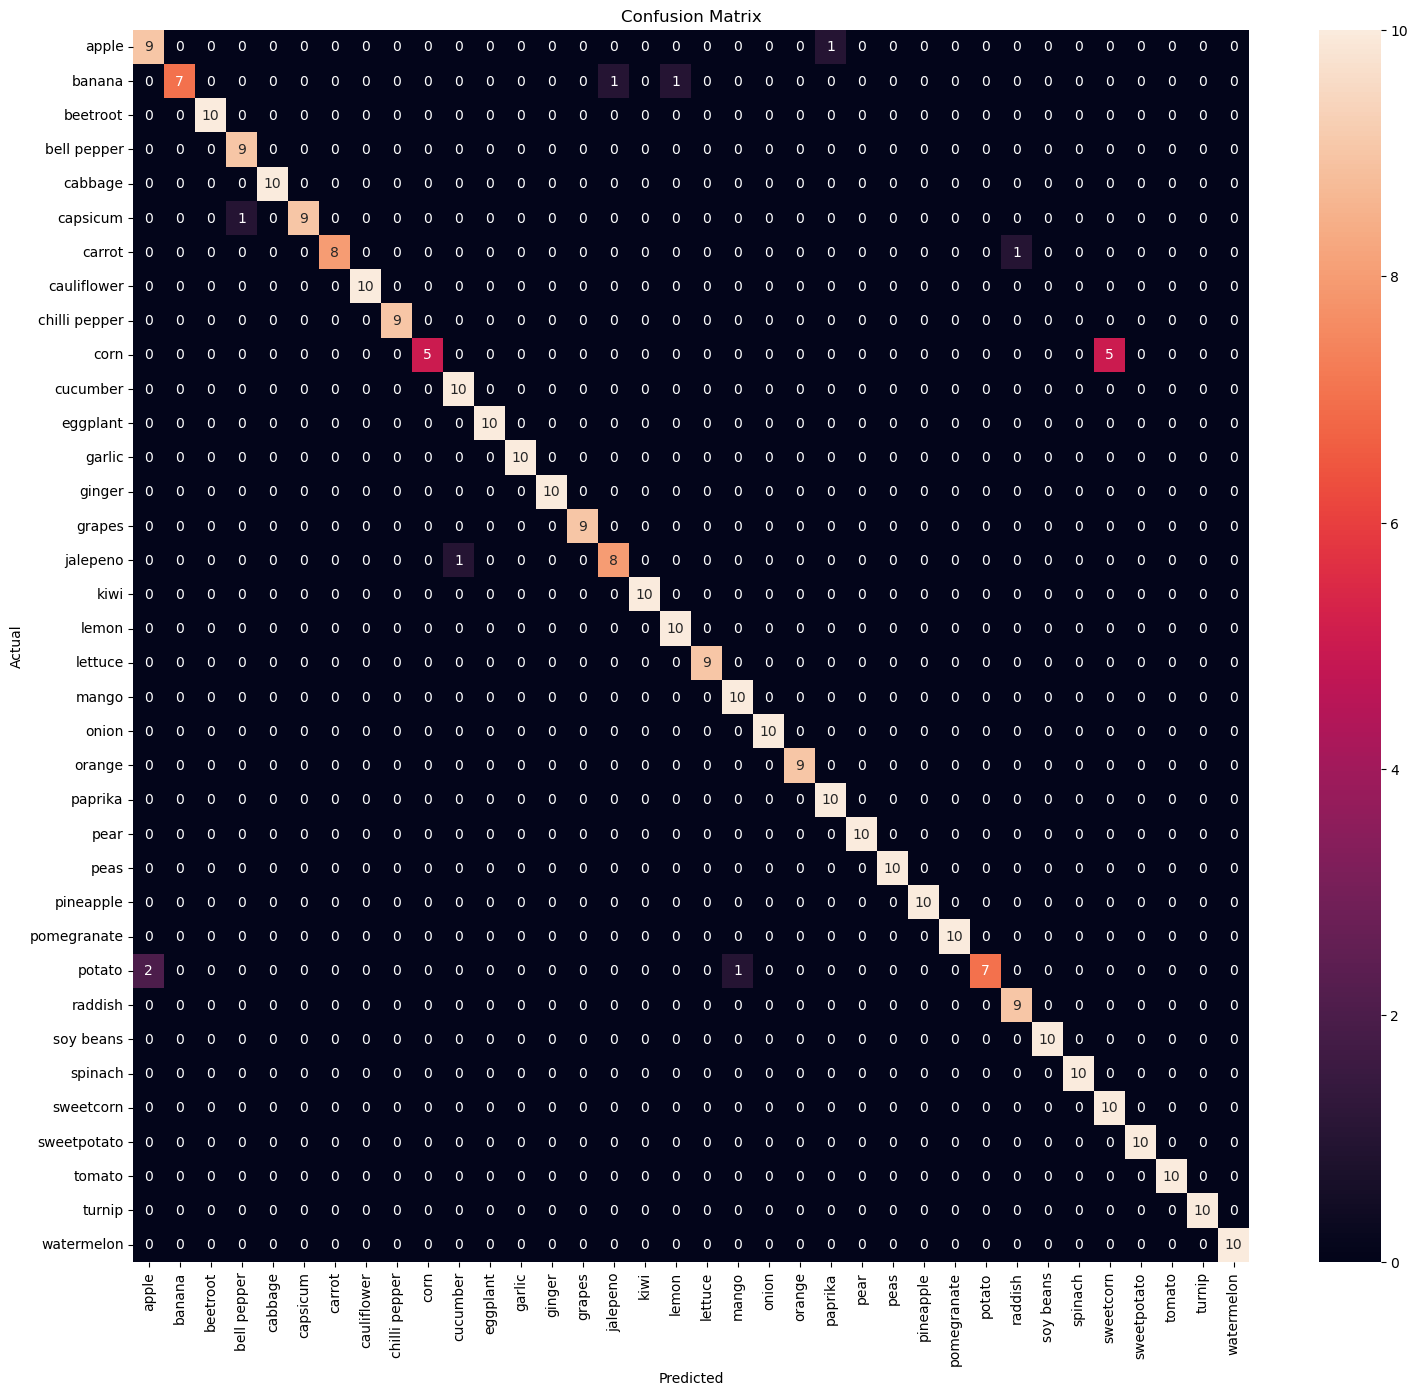

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on validation set
val_preds = model.predict(val_flow)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_flow.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18,16))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=val_flow.class_indices.keys(),
            yticklabels=val_flow.class_indices.keys())
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


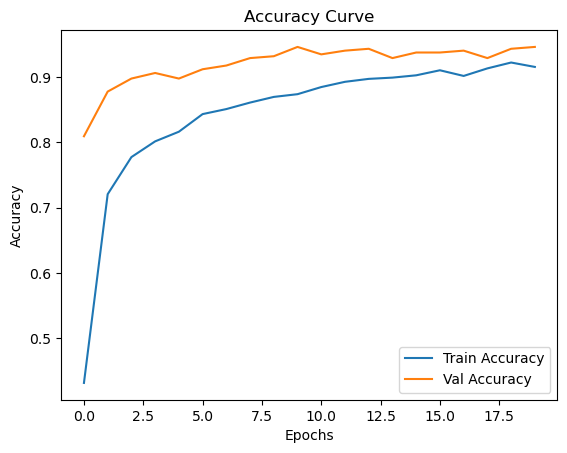

In [63]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


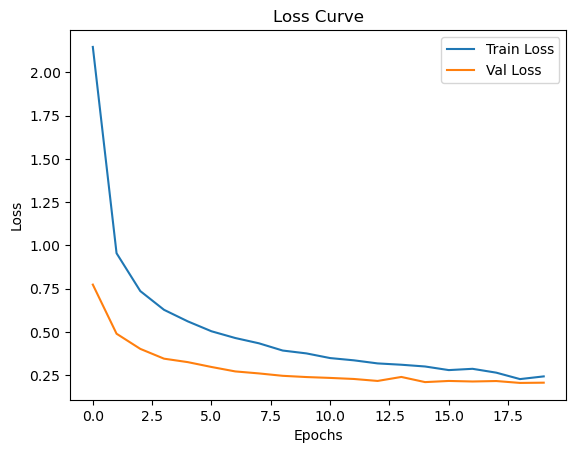

In [64]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
